In [1]:
from  models.imagenet.mbnetv2 import mbnetv2
import torch
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim.lr_scheduler as lr_scheduler


from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
# import logging
import math, os
import pandas as pd

# logging.basicConfig(level=logging.INFO)
# logger = logging.getLogger(__name__)

In [2]:
cfgs = [
            [1,  16, 1, 1],
            [6,  24, 2, 2],
            [6,  32, 3, 2],
            [6,  64, 4, 2],
            
            [6,  96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]
cfgs = [cfg[2] for cfg in cfgs]

In [3]:
type(cfgs)

list

In [4]:
def depth_to_display(depth_1x1HW: torch.Tensor, cmap='magma'):
    # depth_1x1HW: (1,1,H,W)
    d = depth_1x1HW.detach().cpu().float().squeeze(0).squeeze(0)   # (H,W)
    # remove NaN/Inf and clip robustly using percentiles
    a = d.numpy()
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    # robust range (ignore outliers)
    # vmin, vmax = np.percentile(a, 2), np.percentile(a, 98)
    vmin = np.min(a)
    vmax = np.max(a)
    if vmax <= vmin:
        vmin, vmax = float(a.min()), float(a.max())
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-12)

    # grayscale uint8 for saving
    gray_u8 = (norm * 255).astype(np.uint8)

    # optional colored visualization
    plt.figure(figsize=(4,4))
    plt.imshow(norm, cmap=cmap)  # e.g., 'inferno', 'magma', 'turbo', 'viridis'
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # return a  # HxW uint8


### Remapping names to layers for the modified MBnet encoder


In [5]:
def convert_state_dict(pretrained_sd,cfgs):
    new_sd = {}
    for k, v in pretrained_sd.items():
        # print(f"Converting {k} to ")
        # print(v)
        # First layer mapping
        if k.startswith('features.0'):
            new_key = k.replace('features.0', 'first_conv')
            new_sd[new_key] = v
        # Bottleneck blocks mapping (may need to adjust for all indices)
        elif k.startswith('features'):
            parts = k.split('.')
            block_idx = int(parts[1]) - 1      # because features.0 is first_conv
            # Find the corresponding config
            idx_1 = 0
            idx_2 = 0
            for i, cfg in enumerate(cfgs):
                if sum(cfgs[:i+1]) > block_idx:
                    idx_1 = i
                    idx_2 = block_idx - sum(cfgs[:i])
                    break

            rest = '.'.join(parts[2:])
            new_key = f'bottleneck_sequential_blocks.{idx_1}.{idx_2}.{rest}'
            new_sd[new_key] = v
        # Last layers mapping (if present)
        elif k.startswith('conv'):
            new_sd[k] = v
        elif k.startswith('classifier'):
            new_sd[k] = v
        else:
            # Handle or ignore unexpected keys
            pass
    return new_sd

In [6]:
# Load pretrained weights and set up device
pretrained_sd = torch.load('pretrained/mobilenetv2-c5e733a8.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



/tmp/ipykernel_26043/711029353.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_sd = torch.load('pretrained/mobilenetv2-c5e733a8.pth')


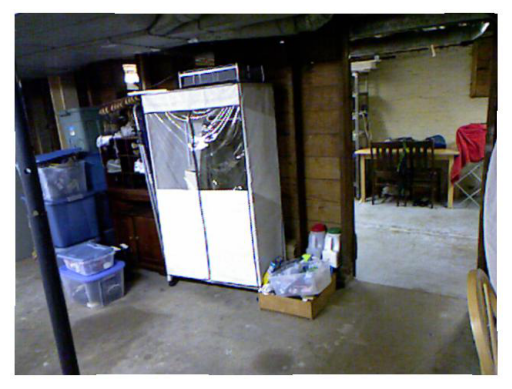

In [7]:

# Load image
img_path = '../nyu_data/data/nyu2_train/basement_0001a_out/1.jpg'
img = Image.open(img_path).convert('RGB')
# Display the image
plt.imshow(img)
plt.axis('off')
plt.show()

img_tensor = transforms.ToTensor()(img).unsqueeze(0)  # add batch dimension

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
img_tensor = img_tensor.to(device)



## Model Classes


In [8]:
def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        assert stride in [1, 2]

        hidden_dim = round(inp * expand_ratio)
        self.identity = stride == 1 and inp == oup

        if expand_ratio == 1:
            self.conv = nn.Sequential(
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
    
    def forward(self, x):
        if self.identity:
            return x + self.conv(x)
        else:
            return self.conv(x)

In [9]:
class PixelShuffleX2(nn.Module):
    def __init__(self, upscale_factor=2):
        super().__init__()
        self.ps = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        x = self.ps(x)
        return x

In [10]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        pixel = PixelShuffleX2
        bottleneck = InvertedResidual

        self.layer1 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(8,80),
            bottleneck(80, 24, stride=1, expand_ratio=1),
            bottleneck(24, 24, stride=1, expand_ratio=8),
            bottleneck(24, 24, stride=1, expand_ratio=8),
            bottleneck(24, 24, stride=1, expand_ratio=6)
        )
        self.depth_conv_1 = nn.Conv2d(24, 1,kernel_size=1,bias=False)
        self.segm_conv_1 = nn.Conv2d(24, 19, kernel_size=1,bias=False)

        self.layer2 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(6,30),
            bottleneck(30, 16, stride=1, expand_ratio=3),
            bottleneck(16, 16, stride=1, expand_ratio=8),
            bottleneck(16, 16, stride=1, expand_ratio=6)
        )
        self.depth_conv_2 = nn.Conv2d(16, 1,kernel_size=1,bias=False)
        self.segm_conv_2 = nn.Conv2d(16, 19, kernel_size=1,bias=False)


        self.layer3 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(4,12),
            bottleneck(12, 8, stride=1, expand_ratio=8),
            bottleneck(8, 8, stride=1, expand_ratio=8),
            bottleneck(8, 8, stride=1, expand_ratio=8)
        )
        self.depth_conv_3 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_3 = nn.Conv2d(8, 19, kernel_size=1,bias=False)

        self.layer4 = nn.Sequential(
            pixel(4),
            # nn.GroupNorm(1,2),
            bottleneck(2, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_4 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_4 = nn.Conv2d(8, 19, kernel_size=1,bias=False)

    def forward(self, x, skips):
        depth_imgs=[]
        segm_imgs=[]
        out1 = self.layer1(x)
        depth_imgs.append(self.depth_conv_1(out1))
        # segm_imgs.append(F.softmax(self.segm_conv_1(out1), dim=1))

        out1 = torch.cat((out1, skips[4]), dim=1)  # Skip connection
        out2 = self.layer2(out1)
        depth_imgs.append(self.depth_conv_2(out2))
        # segm_imgs.append(F.softmax(self.segm_conv_2(out2), dim=1))

        out2 = torch.cat((out2, skips[2]), dim=1)  # Skip connection
        out3 = self.layer3(out2)
        depth_imgs.append(self.depth_conv_3(out3))
        # segm_imgs.append(F.softmax(self.segm_conv_3(out3), dim=1))

        out3 = torch.cat((out3, skips[1]), dim=1)  # Skip connection
        out4 = self.layer4(out3)
        depth_imgs.append(self.depth_conv_4(out4))
        # segm_imgs.append(F.softmax(self.segm_conv_4(out4), dim=1))

        depth_imgs = [img.squeeze(dim=1).to(torch.float32) for img in depth_imgs]
        return depth_imgs

In [11]:
class MainModel(nn.Module):
    def __init__(self,pretrained_sd):
        super().__init__()
        self.encoder = mbnetv2()
        converted_sd = convert_state_dict(pretrained_sd, cfgs)
        self.encoder.load_state_dict(converted_sd)

        for i in self.encoder.parameters():
            i.requires_grad = False

        self.decoder = Decoder()

    def forward(self, x):
        enc_out = self.encoder(x)
        dec_out = self.decoder(enc_out[0], enc_out[1])
        return dec_out

In [12]:
model = MainModel(pretrained_sd)
model.to(device)


Initializing weights...


MainModel(
  (encoder): MobileNetV2(
    (first_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (bottleneck_sequential_blocks): ModuleList(
      (0): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
            (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (1): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(16, 96, kernel_size=(1, 1), str

### Verify stuff

Test out the model and verify dimensions


In [13]:
dec_out = model(img_tensor)

In [14]:
for i in dec_out:
    print(i.shape)

torch.Size([1, 30, 40])
torch.Size([1, 60, 80])
torch.Size([1, 120, 160])
torch.Size([1, 480, 640])


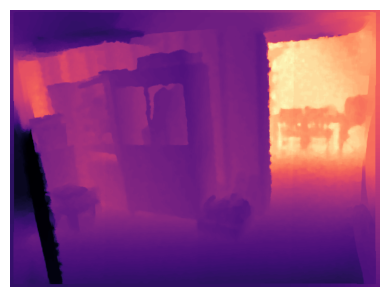

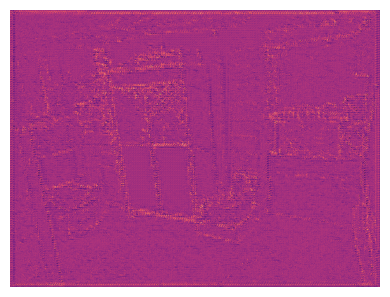

In [15]:
depth_path = '../nyu_data/data/nyu2_train/basement_0001a_out/1.png'
gt_depth = Image.open(depth_path)
depth_tensor = transforms.ToTensor()(gt_depth).unsqueeze(0)  # add batch dimension
depth_tensor = depth_tensor.to(device)
# plt.imshow(gt_depth)
depth_to_display(depth_tensor)  # (1,1,H,W)
depth_to_display(dec_out[3])  # (1,1,H,W)



### LOSS FUNCTIONS


In [16]:
class DepthLoss(nn.Module):

    def __init__(self, m=4, M=80):
        super(DepthLoss, self).__init__()
        self.m = m  # lower bound for log transform
        self.M = M  # upper bound for log transform
    
    def log_transform(self, depth):

        log_depth = torch.log(torch.clamp(depth, min=self.m, max=self.M))
        log_m = math.log(self.m)
        log_M = math.log(self.M)
        
        return (log_depth - log_m) * self.M / (log_M - log_m)
    
    def berhu_loss(self, pred, target, c):
 
        diff = torch.abs(pred - target)
        l1_mask = diff <= c
        l1_loss = diff
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        
        return torch.where(l1_mask, l1_loss, l2_loss)
    
    def forward(self, pred_depth, gt_depth):
        pred_log = self.log_transform(pred_depth)
        gt_log = self.log_transform(gt_depth)
        
        diff = torch.abs(pred_log - gt_log)
        c = 0.2 * torch.max(diff)  
        # Apply BerHu loss
        berhu_losses = self.berhu_loss(pred_log, gt_log, c)
        
        # Average over spatial dimensions
        B, H, W = pred_depth.shape
        loss = torch.sum(berhu_losses) / (B * H * W)
        
        return loss

In [17]:
class MultiScaleDepthLoss(nn.Module):
    def __init__(self, m=0.1, M=10.0):
        super(MultiScaleDepthLoss, self).__init__()
        self.m = m
        self.M = M
        
        # Pre-calculate constants for the G(d) transform for efficiency
        self.log_m = math.log(self.m)
        self.log_M = math.log(self.M)
        self.log_M_minus_log_m = self.log_M - self.log_m

    def _g_transform(self, d):

        # Clamp depth values to the valid range [m, M]
        d_clamped = torch.clamp(d, min=self.m, max=self.M)
        log_d = torch.log(d_clamped)
        
        # Apply the transformation formula
        return (log_d - self.log_m) * self.M / self.log_M_minus_log_m

    def _berhu_loss(self, diff, c):

        # L1 loss for small differences
        l1_loss = diff
        # L2-like loss for large differences
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        # Combine using a mask
        mask = diff <= c
        return torch.where(mask, l1_loss, l2_loss)

    def forward(self, pred_depths, gt_depth):

        total_loss = 0.0
        scale = [0.3, 0.5, 0.75, 1.0]

        for i,pred_d in enumerate(pred_depths):
            _, H_i, W_i = pred_d.shape
            
            resized_gt_d = F.interpolate(gt_depth, size=(H_i, W_i), mode='bilinear', align_corners=True)
            resized_gt_d = resized_gt_d.squeeze(dim=1).to(torch.float32)

            # Apply the G-transform to both prediction and resized ground truth
            pred_g = self._g_transform(pred_d)
            gt_g = self._g_transform(resized_gt_d)
            diff = torch.abs(pred_g - gt_g)
            c = 0.2 * torch.max(diff).detach()
            
            # Calculate the BerHu loss for every pixel
            berhu_pixel_losses = self._berhu_loss(diff, c)
            
            scale_loss = torch.sum(berhu_pixel_losses) / ( H_i * W_i)  # Average over batch and spatial dimensions
            total_loss += scale_loss
            
        return total_loss

In [18]:
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, data_range=1.0, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.data_range = data_range
        self.size_average = size_average
        
        # Create Gaussian window (1, 1, window_size, window_size)
        self.window = self._create_window(window_size)
        
    def _gaussian(self, window_size, sigma=1.5):
        gauss = torch.Tensor([
            math.exp(-(x - window_size//2)**2 / (2*sigma**2)) 
            for x in range(window_size)
        ])
        return gauss / gauss.sum()
    
    def _create_window(self, window_size):
        _1D_window = self._gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float()
        window = _2D_window.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 11, 11)
        return window
    
    def forward(self, pred, target):
        pred = pred[-1]
        # Add channel dimension: (B, H, W) -> (B, 1, H, W)
        if pred.dim() == 3:
            pred = pred.unsqueeze(1)
            # target = target.unsqueeze(1)
        
        # batch_size = pred.size(0)
        
        # Ensure window is on same device
        if self.window.device != pred.device:
            self.window = self.window.to(pred.device)
        
        # Use the single-channel window
        window = self.window
        
        # Compute local means
        mu1 = F.conv2d(pred, window, padding=self.window_size//2)
        mu2 = F.conv2d(target, window, padding=self.window_size//2)
        
        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2
        
        # Compute local variances and covariance
        sigma1_sq = F.conv2d(pred * pred, window, padding=self.window_size//2) - mu1_sq
        sigma2_sq = F.conv2d(target * target, window, padding=self.window_size//2) - mu2_sq
        sigma12 = F.conv2d(pred * target, window, padding=self.window_size//2) - mu1_mu2
        
        # SSIM constants
        C1 = (0.01 * self.data_range) ** 2
        C2 = (0.03 * self.data_range) ** 2
        
        # SSIM formula
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Average over spatial dimensions, optionally over batch
        if self.size_average:
            return 1 - ssim_map.mean()  # Convert to loss
        else:
            return 1 - ssim_map.mean(dim=[1, 2, 3])  # Per-batch losses

In [19]:
def edge_aware_smoothness_loss( pred, depth):    
    # Compute gradients
    pred = pred[-1]
    depth = depth.squeeze(dim=1).to(torch.float32)
    depth_grad_x = torch.abs(depth[:, :, :-1] - depth[:, :, 1:])
    depth_grad_y = torch.abs(depth[:, :-1, :] - depth[:, 1:, :])

    image_grad_x = torch.abs(pred[:,  :, :-1] - pred[:,  :, 1:])
    image_grad_y = torch.abs(pred[:,  :-1, :] - pred[:, 1:, :])

    # Edge-aware weighting
    # smooth_x = depth_grad_x * torch.exp(-image_grad_x)
    # smooth_y = depth_grad_y * torch.exp(-image_grad_y)
    loss = torch.sum(torch.abs(depth_grad_x - image_grad_x)) + torch.sum(torch.abs(depth_grad_y - image_grad_y))
    loss /= (pred.size(1) * pred.size(2))

    return loss


In [20]:
loss = MultiScaleDepthLoss()
depth_tensor = depth_tensor.float()
testing_loss = edge_aware_smoothness_loss(dec_out, depth_tensor)
print(testing_loss.item(),loss(dec_out, depth_tensor).item())


1.920943260192871 12.5485200881958


## Dataset Prep


In [21]:
train_csv = '../nyu_data/data/nyu2_train.csv'
base_path = '../nyu_data'
df = pd.read_csv(train_csv, header=None)
df[0] = df[0].map(lambda x: base_path+"/"+x) # Prepending the base path
df[1] = df[1].map(lambda x: base_path+"/"+x)

In [22]:
df.iloc[0,0], df.iloc[0,1]  # Checking the paths

('../nyu_data/data/nyu2_train/living_room_0038_out/37.jpg',
 '../nyu_data/data/nyu2_train/living_room_0038_out/37.png')

In [23]:
df.head()

,0,1
0,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
1,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
2,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
3,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
4,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...


In [ ]:
class DepthDataset(Dataset):

    def __init__(self, df, image_transform=None, depth_transform=None):
    
        self.df = df
        self.image_transform = image_transform
        self.depth_transform = depth_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get the file paths from the dataframe at the given index
        image_path = self.df.iloc[idx, 0]
        depth_path = self.df.iloc[idx, 1]
        
        # Load the image and depth map using PIL
        image = transforms.ToTensor()(Image.open(image_path))
        depth = transforms.ToTensor()(Image.open(depth_path))

        # Apply transformations if they are provided
        if self.image_transform:
            image = self.image_transform(image)
        
        if self.depth_transform:
            depth = self.depth_transform(depth)
        print(image.shape, depth.shape)
        return image, depth
    

In [25]:
dataset_depth = DepthDataset(df)
data_loader_depth = DataLoader(dataset_depth, batch_size=8, shuffle=True, num_workers=2)
for batch in data_loader_depth:
    print(batch[0].shape)  # Should be (B, 3, H, W)
    print(batch[1].shape)  # Should be (B, 1, H, W)
    break

torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640])torch.Size([3, 480, 640])  torch.Size([1, 480, 640])torch.Size([1, 480, 640])

torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([

In [26]:
from torch.optim.lr_scheduler import _LRScheduler

In [27]:
class DecayingRestartScheduler(_LRScheduler):
    def __init__(self, optimizer, T_restart=50, restart_decay=0.8, eta_min=1e-6, last_epoch=-1):

        self.T_restart = T_restart
        self.restart_decay = restart_decay
        self.eta_min = eta_min
        self.current_restart_peak = None
        self.restart_count = 0
        
        super().__init__(optimizer, last_epoch)
    
    def get_lr(self):
        if self.current_restart_peak is None:
            # First time - use base LR
            self.current_restart_peak = self.base_lrs[0]
        
        # Check if we're at a restart point
        if self.last_epoch > 0 and self.last_epoch % self.T_restart == 0:
            # Decay the restart peak
            self.current_restart_peak *= self.restart_decay
            self.restart_count += 1
            # Don't let peak go below minimum
            self.current_restart_peak = max(self.current_restart_peak, self.eta_min)
        
        # Calculate position in current cycle
        cycle_progress = (self.last_epoch % self.T_restart) / self.T_restart
        
        # Cosine decay from current peak to minimum
        current_lr = self.eta_min + (self.current_restart_peak - self.eta_min) * \
                     (1 + math.cos(math.pi * cycle_progress)) / 2
        
        return [current_lr for _ in self.base_lrs]

# Usage
# optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)


In [28]:
def train_multi_scale_depth_model(model, dataloader, num_epochs=100, lr=1e-2):
    # # Initialize dataset and dataloader
    # dataset = DepthDataset(dataset_folder)
    # dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize loss function and optimizer
    depth_loss = MultiScaleDepthLoss()
    ssim_loss = SSIMLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    # scheduler = StepLR(optimizer, step_size=1, gamma=0.9)
    # Cosine Annealing with Warm Restarts
    # scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
    #     optimizer,
    #     T_0=10,        # Epochs until first restart
    #     T_mult=2,      # Multiply restart period by this factor
    #     eta_min=1e-4  # Minimum learning rate
    # )
    scheduler = DecayingRestartScheduler(
        optimizer,
        T_restart=10,      # Restart every 20 iterations
        restart_decay=0.5,  # Each restart peak is 70% of previous
        eta_min=1e-8       # Minimum LR bound
    )


    # Scale weights for different depth layers (coarse to fine)
    # scale_weights = [1, 1, 1, 1.0]  # Give more weight to finer scales
    
    model.train()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for batch_idx, (color_input, depth_gt) in enumerate(dataloader):

            if batch_idx > 1000:
                break
            if batch_idx % 50 == 0:
                # print(f"Processing batch {batch_idx} of epoch {epoch}")
                scheduler.step()
            color_input = color_input.to(device, non_blocking=True)
            depth_gt = depth_gt.to(device, non_blocking=True)
            
            # Ensure data types are consistent
            color_input = color_input.float()
            depth_gt = depth_gt.float()
            
            optimizer.zero_grad()
            
            # Forward pass through model - returns list of 4 depth predictions
            depth_predictions = model(color_input)  # List of 4 tensors at different scales

            total_loss = depth_loss(depth_predictions, depth_gt) #+ edge_aware_smoothness_loss(depth_predictions, depth_gt) + ssim_loss(depth_predictions, depth_gt) 

            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            
            # Print progress
            if batch_idx % 50 == 0:
                print(f'Epoch {epoch}/{num_epochs}, Batch {batch_idx}, '
                      f'Total Loss: {total_loss.item():.4f}, ')
                    #   f'Layer Losses: {[f"{l:.4f}" for l in layer_losses]}')
        
        print(f'Epoch {epoch} completed. Average Loss: {epoch_loss/len(dataloader):.4f}')
        # scheduler.step()

In [29]:
# def train_multi_scale_depth_model_with_checks(model, dataset_folder, num_epochs=100, batch_size=4, lr=1e-4):
#     # Explicit device checking
#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#         print("CUDA is available! Training on GPU...")
#     else:
#         device = torch.device('cpu')
#         print("CUDA is not available. Training on CPU...")
    
#     # Move model to device
#     # model = model.to(device)
    
#     # Initialize dataset and dataloader
#     dataset = DepthDataset(dataset_folder)
#     dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
#                           pin_memory=torch.cuda.is_available(), num_workers=2)
    
#     # Initialize loss function and optimizer
#     depth_loss = DepthLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
#     # Scale weights for different depth layers
#     scale_weights = [0.5, 0.7, 0.9, 1.0]
    
#     model.train()
    
#     for epoch in range(num_epochs):
#         epoch_loss = 0.0
        
#         for batch_idx, (color_input, depth_gt) in enumerate(dataloader):
#             # Move tensors to GPU if CUDA is available
#             color_input = color_input.to(device, non_blocking=True)
#             depth_gt = depth_gt.to(device, non_blocking=True)
            
#             # Ensure data types are consistent
#             color_input = color_input.float()
#             depth_gt = depth_gt.float()
            
#             optimizer.zero_grad()
            
#             # Forward pass through model
#             depth_predictions = model(color_input)
            
#             total_loss = 0.0
#             layer_losses = []
            
#             # Compute loss for each depth layer
#             for i, (pred_depth, weight) in enumerate(zip(depth_predictions, scale_weights)):
#                 # Resize ground truth to match prediction resolution if needed
#                 if pred_depth.shape[-2:] != depth_gt.shape[-2:]:
#                     depth_gt_resized = torch.nn.functional.interpolate(
#                         depth_gt, size=pred_depth.shape[-2:], mode='bilinear', align_corners=False
#                     )
#                 else:
#                     depth_gt_resized = depth_gt
                
#                 # Compute loss for this layer
#                 layer_loss = depth_loss(pred_depth, depth_gt_resized)
#                 weighted_loss = weight * layer_loss
#                 total_loss += weighted_loss
#                 layer_losses.append(layer_loss.item())
            
#             # Backward pass
#             total_loss.backward()
#             optimizer.step()
            
#             epoch_loss += total_loss.item()
            
#             # Print progress
#             if batch_idx % 10 == 0:
#                 print(f'Epoch {epoch}/{num_epochs}, Batch {batch_idx}, '
#                       f'Total Loss: {total_loss.item():.4f}, '
#                       f'Device: {color_input.device}, '
#                       f'Layer Losses: {[f"{l:.4f}" for l in layer_losses]}')
        
#         print(f'Epoch {epoch} completed. Average Loss: {epoch_loss/len(dataloader):.4f}')



In [ ]:
train_multi_scale_depth_model(model, data_loader_depth, num_epochs=20, lr=1e-6)

torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([

/home/utsab/miniconda3/envs/IRL_AGV/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([3, 480, 640])torch.Size([1, 480, 640]) 
torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
torch.Size([3, 480, 640]) torch.Size([1, 480, 640])
Epoch 0/20, Batch 0, Total Loss: 85.4149, 
torch.Size([3, 480, 6

In [ ]:
output = model(img_tensor)
print(MultiScaleDepthLoss()(output, depth_tensor).item(), edge_aware_smoothness_loss(output, depth_tensor).item(), SSIMLoss()(output, depth_tensor).item())

3.949131965637207 0.039837710559368134 0.4360494613647461


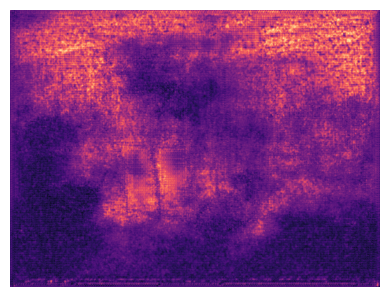

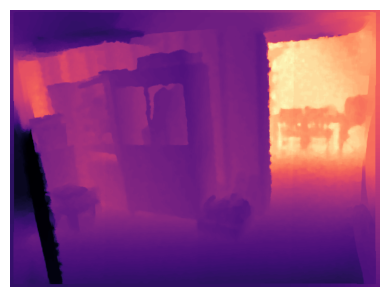

In [ ]:
depth_to_display(output[3])  # (1,1,H,W)
depth_to_display(depth_tensor)  # (1,1,H,W)

In [ ]:
mbnetv2 = mbnetv2()

Initializing weights...


In [ ]:
encoder_params = sum(p.numel() for p in mbnetv2.parameters())
print(f'Encoder parameters: {encoder_params}')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters: {total_params}')
print(f'Total decoder parameters: {total_params - encoder_params}')


Encoder parameters: 3504872
Total number of parameters: 3556290
Total decoder parameters: 51418


In [ ]:
def rmse(pred, target):
    pred = pred[-1]
    return torch.sqrt(torch.mean((pred - target) ** 2))

In [ ]:
rmse(output, depth_tensor)

tensor(0.1366, device='cuda:0', grad_fn=<SqrtBackward0>)

In [ ]:
print(torch.max(output[3]).item(),
torch.max(depth_tensor).item(),
torch.min(torch.abs(output[3]-depth_tensor)).item())

0.8895604610443115 0.658823549747467 1.1920928955078125e-07


In [ ]:
# torch.save(model.state_dict(), '../saves/v2.pth')


In [ ]:
def smooth_depth_prediction(depth_tensor, kernel_size=5):
    """Apply Gaussian smoothing to reduce noise"""
    import torch.nn.functional as F
    
    # Create Gaussian kernel
    sigma = kernel_size / 3.0
    kernel_1d = torch.exp(-0.5 * (torch.arange(kernel_size) - kernel_size//2)**2 / sigma**2)
    kernel_1d = kernel_1d / kernel_1d.sum()
    
    # 2D separable Gaussian
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.unsqueeze(0).unsqueeze(0).to(depth_tensor.device)
    
    # Apply smoothing
    smooth_depth = F.conv2d(depth_tensor, kernel_2d, padding=kernel_size//2)
    return smooth_depth

# Use during inference
with torch.no_grad():
    raw_pred = model(img_tensor)
    smooth_pred = smooth_depth_prediction(raw_pred[-1])


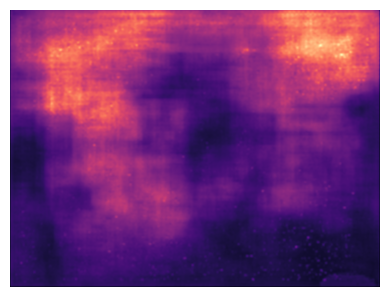

In [ ]:
depth_to_display(smooth_pred)